# RQ3: Are the determinants of mortgage approval and the magnitude of demographic disparities stable over time?

This notebook studies whether the main determinants of mortgage approval remain stable across years and whether demographic disparities change over time.

The main idea is simple:

1. Use a pooled logistic regression to estimate the relationship between approval and key applicant characteristics.
2. Add interaction terms between race and year to test whether demographic gaps shift over time.
3. Compare predicted approval probabilities across racial groups and years.

The dependent variable is `approved`, where 1 means the application was approved and 0 means it was denied.

The main demographic variables are `derived_race` and `derived_sex`, which were created in the data preparation notebook.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## Step 1. Load the cleaned data

This file is already cleaned, so I do not need to recreate the approval variable from `action_taken`.

In [2]:
downloads_path = os.path.expanduser("~/Downloads")

file_path = os.path.join(downloads_path, "hmda_2022_2025_cleaned_for_rq3.csv")

df = pd.read_csv(file_path, low_memory=False)

print("Shape:", df.shape)
print(df.columns.tolist())
print(df.head())

Shape: (3359575, 15)
['activity_year', 'approved', 'income', 'loan_amount', 'preapproval', 'derived_race', 'derived_sex', 'loan_type', 'loan_purpose', 'lien_status', 'construction_method', 'occupancy_type', 'property_value', 'aus_1', 'dti_ordinal']
   activity_year  approved  income  loan_amount  preapproval  derived_race  \
0           2022         1    77.0       115000            2           5.0   
1           2022         1    83.0       105000            2           5.0   
2           2022         1    32.0        85000            2           3.0   
3           2022         1   126.0       225000            2           5.0   
4           2022         1    54.0        25000            2           5.0   

   derived_sex  loan_type  loan_purpose  lien_status  construction_method  \
0            1          1            31            1                    1   
1            2          1            31            1                    1   
2            2          1             4            

## Step 2. Basic cleaning

The cleaned dataset already contains `approved`, so I only need to:
- keep valid approval values
- convert important numeric columns
- drop missing values in the main variables

In [3]:
needed_cols = [
    "activity_year",
    "approved",
    "income",
    "loan_amount",
    "derived_race",
    "derived_sex"
]

missing_cols = [col for col in needed_cols if col not in df.columns]

print("Missing columns:", missing_cols)

if len(missing_cols) > 0:
    raise ValueError("Some required columns are missing.")

Missing columns: []


In [4]:
# Clean key variables
df["activity_year"] = pd.to_numeric(df["activity_year"], errors="coerce")
df["approved"] = pd.to_numeric(df["approved"], errors="coerce")
df["income"] = pd.to_numeric(df["income"], errors="coerce")
df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")

df["derived_race"] = df["derived_race"].astype(str)
df["derived_sex"] = df["derived_sex"].astype(str)

df = df.dropna(
    subset=[
        "activity_year",
        "approved",
        "income",
        "loan_amount",
        "derived_race",
        "derived_sex"
    ]
).copy()

df = df[df["approved"].isin([0, 1])].copy()

print("Cleaned shape:", df.shape)
print(df["activity_year"].value_counts().sort_index())
print(df["approved"].value_counts())

Cleaned shape: (3359575, 15)
activity_year
2022    1037974
2023     731925
2024     771126
2025     818550
Name: count, dtype: int64
approved
1    2599043
0     760532
Name: count, dtype: int64


## Step 3. Simplify race categories

The cleaned file uses many race codes. For this RQ, I only want a simple comparison across major demographic groups.

I create:
- White
- Black
- Asian
- Hispanic
- Other

This makes the plots and interpretation much clearer.

In [5]:
def clean_code(x):
    try:
        return str(int(float(x)))
    except:
        return str(x)


df["race_code"] = df["derived_race"].apply(clean_code)
df["sex_code"] = df["derived_sex"].apply(clean_code)


race_map = {
    "1": "Other",
    "2": "Asian",
    "3": "Black",
    "4": "Other",
    "5": "White",
    "6": "Other",
    "7": "Other"
}

sex_map = {
    "1": "Male",
    "2": "Female",
    "3": "Other",
    "4": "Other",
    "5": "Other",
    "6": "Other"
}

df["race_group"] = df["race_code"].map(race_map).fillna("Other")
df["sex_group"] = df["sex_code"].map(sex_map).fillna("Other")

print(df["race_group"].value_counts())
print(df["sex_group"].value_counts())

race_group
White    2265970
Other     604470
Black     305157
Asian     183978
Name: count, dtype: int64
sex_group
Male      1969942
Female    1157840
Other      231793
Name: count, dtype: int64


## Step 4. Descriptive statistics

Before running the regressions, I look at some basic summary statistics.

   activity_year  approved
0           2022  0.786229
1           2023  0.757949
2           2024  0.763709
3           2025  0.780991


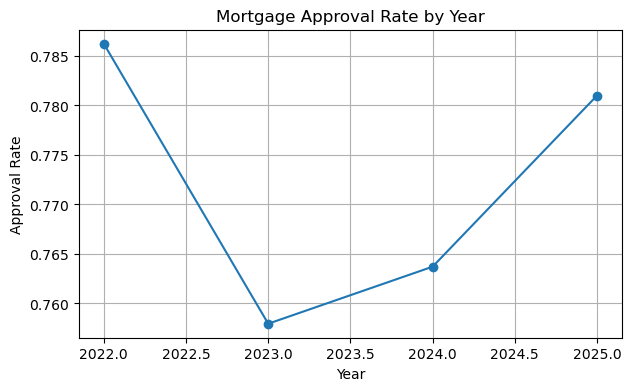

In [6]:
approval_by_year = (
    df.groupby("activity_year")["approved"]
    .mean()
    .reset_index()
)

print(approval_by_year)

plt.figure(figsize=(7, 4))
plt.plot(
    approval_by_year["activity_year"],
    approval_by_year["approved"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Approval Rate")
plt.title("Mortgage Approval Rate by Year")
plt.grid(True)
plt.show()

The plot shows how the overall mortgage approval rate changes over time. This gives a first look at whether approval patterns are stable across years.

## Step 5. Approval rates by year

This first figure shows whether average approval rates move over time.

   activity_year race_group  approved
0           2022      Asian  0.816348
1           2022      Black  0.674806
2           2022      Other  0.735339
3           2022      White  0.812395
4           2023      Asian  0.800466


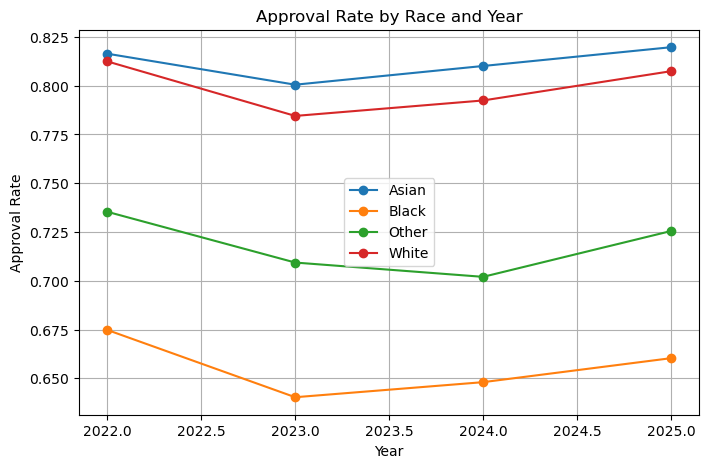

In [7]:
approval_race_year = (
    df.groupby(["activity_year", "race_group"])["approved"]
    .mean()
    .reset_index()
)

print(approval_race_year.head())

plt.figure(figsize=(8, 5))

for race in approval_race_year["race_group"].unique():
    temp = approval_race_year[approval_race_year["race_group"] == race]
    plt.plot(
        temp["activity_year"],
        temp["approved"],
        marker="o",
        label=race
    )

plt.xlabel("Year")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Race and Year")
plt.legend()
plt.grid(True)
plt.show()

This figure compares approval rates across racial groups over time. If the lines stay in a similar order across years, this suggests that racial differences are relatively stable. If the lines cross or move sharply, this suggests that disparities may be changing over time.

## Step 6. Approval rates by race and year

This gives a first descriptive look at demographic disparities before the regression analysis.

In [8]:
# The full dataset is very large, so I use a random sample for regression.
# This makes the model run faster while keeping the analysis manageable.

model_df = df[
    [
        "approved",
        "income",
        "loan_amount",
        "activity_year",
        "race_group",
        "sex_group"
    ]
].dropna().copy()

model_df = model_df[
    (model_df["income"] >= 0) &
    (model_df["loan_amount"] > 0)
].copy()

# use sample for faster regression
sample_size = 200000

if len(model_df) > sample_size:
    model_df = model_df.sample(n=sample_size, random_state=42)

print("Model sample shape:", model_df.shape)
print(model_df.head())

Model sample shape: (200000, 6)
         approved  income  loan_amount  activity_year race_group sex_group
856950          1    35.0        15000           2022      White      Male
2545515         0   140.0       435000           2025      Other    Female
641410          1   158.0       405000           2022      Asian      Male
2552907         1   152.0       515000           2025      White      Male
2293991         1   268.0       115000           2024      White      Male


## Step 7. Baseline pooled logistic regression

I first estimate a simple pooled model with the main variables:
- income
- loan amount
- race
- sex
- year

This shows whether the main determinants of mortgage approval are generally stable in the pooled sample.

In [9]:
formula_base = "approved ~ income + loan_amount + C(race_group) + C(sex_group) + C(activity_year)"

model_base = smf.logit(
    formula=formula_base,
    data=model_df
).fit(disp=False)

print(model_base.summary())

                           Logit Regression Results                           
Dep. Variable:               approved   No. Observations:               200000
Model:                          Logit   Df Residuals:                   199989
Method:                           MLE   Df Model:                           10
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.03730
Time:                        07:27:15   Log-Likelihood:            -1.0292e+05
converged:                       True   LL-Null:                   -1.0691e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.6946      0.029     23.959      0.000       0.638       0.751
C(race_group)[T.Black]      -0.4443      0.030    -14.923      0.000      -0.503      -0.

## Step 8. Interaction model

To answer the research question more directly, I allow race effects to vary by year.

The interaction terms between `race_simple` and `activity_year` help test whether demographic disparities are stable over time or whether they shift across years.

In [10]:
formula_interact = "approved ~ income + loan_amount + C(race_group) * C(activity_year) + C(sex_group)"

model_interact = smf.logit(
    formula=formula_interact,
    data=model_df
).fit(disp=False)

print(model_interact.summary())

                           Logit Regression Results                           
Dep. Variable:               approved   No. Observations:               200000
Model:                          Logit   Df Residuals:                   199980
Method:                           MLE   Df Model:                           19
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.03732
Time:                        07:27:23   Log-Likelihood:            -1.0292e+05
converged:                       True   LL-Null:                   -1.0691e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                           0.6579      0.047     14.077      0.000       0.566       0.750
C(race_group)[T.Blac

If the race-year interaction terms are small or not statistically significant, this suggests that racial disparities are relatively stable across years.

If the interaction terms are large or statistically significant, this suggests that disparities changed over time.

## Step 9. Separate regressions by year

As an additional check, I run the same model separately for each year.

This is useful for seeing whether the signs and relative importance of the main variables look similar across years.

In [11]:
years = sorted(model_df["activity_year"].dropna().unique())

for year in years:
    print("=" * 80)
    print(f"Results for {year}")
    
    df_year = model_df[model_df["activity_year"] == year].copy()
    
    try:
        model_year = smf.logit(
            "approved ~ income + loan_amount + C(race_group) + C(sex_group)",
            data=df_year
        ).fit(disp=False)
        
        print(model_year.summary())
        
    except Exception as e:
        print(f"Model for {year} could not be estimated:", e)

Results for 2022
                           Logit Regression Results                           
Dep. Variable:               approved   No. Observations:                61764
Model:                          Logit   Df Residuals:                    61756
Method:                           MLE   Df Model:                            7
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.03604
Time:                        07:27:27   Log-Likelihood:                -31107.
converged:                       True   LL-Null:                       -32270.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.6169      0.051     12.042      0.000       0.517       0.717
C(race_group)[T.Black]    -0.4054      0.054     -7.465      0.000      -0.512

Running separate models by year helps check whether the direction and size of race coefficients look similar across years.

## Step 10. Predicted probabilities

Raw logit coefficients are not always easy to interpret.  
So I compute predicted approval probabilities for a simple profile:

- income fixed at the sample median
- loan amount fixed at the sample median
- sex fixed at the most common category

Then I compare predicted approval probabilities across racial groups and years.

In [12]:
median_income = model_df["income"].median()
median_loan = model_df["loan_amount"].median()
chosen_sex = model_df["sex_group"].mode()[0]

race_levels = ["White", "Black", "Asian", "Other"]
years = sorted(model_df["activity_year"].dropna().unique())

pred_grid = pd.DataFrame([
    {
        "income": median_income,
        "loan_amount": median_loan,
        "race_group": race,
        "sex_group": chosen_sex,
        "activity_year": year
    }
    for race in race_levels
    for year in years
])

pred_grid["predicted_prob"] = model_interact.predict(pred_grid)

print(pred_grid)

    income  loan_amount race_group sex_group  activity_year  predicted_prob
0    101.0     205000.0      White      Male           2022        0.805792
1    101.0     205000.0      White      Male           2023        0.785232
2    101.0     205000.0      White      Male           2024        0.792079
3    101.0     205000.0      White      Male           2025        0.802765
4    101.0     205000.0      Black      Male           2022        0.672575
5    101.0     205000.0      Black      Male           2023        0.660110
6    101.0     205000.0      Black      Male           2024        0.657650
7    101.0     205000.0      Black      Male           2025        0.670939
8    101.0     205000.0      Asian      Male           2022        0.758493
9    101.0     205000.0      Asian      Male           2023        0.755033
10   101.0     205000.0      Asian      Male           2024        0.752157
11   101.0     205000.0      Asian      Male           2025        0.760456
12   101.0  

In [17]:
table43 = pred_grid.pivot(
    index="race_group",
    columns="activity_year",
    values="predicted_prob"
).round(3)

table43

activity_year,2022,2023,2024,2025
race_group,,,,
Asian,0.758,0.755,0.752,0.760
Black,0.673,0.660,0.658,0.671
Other,0.717,0.696,0.698,0.717
White,0.806,0.785,0.792,0.803


## Step 11. Predicted approval probability by race and year

This figure shows whether predicted approval probabilities are parallel over time or whether some groups gain or lose relative to others.

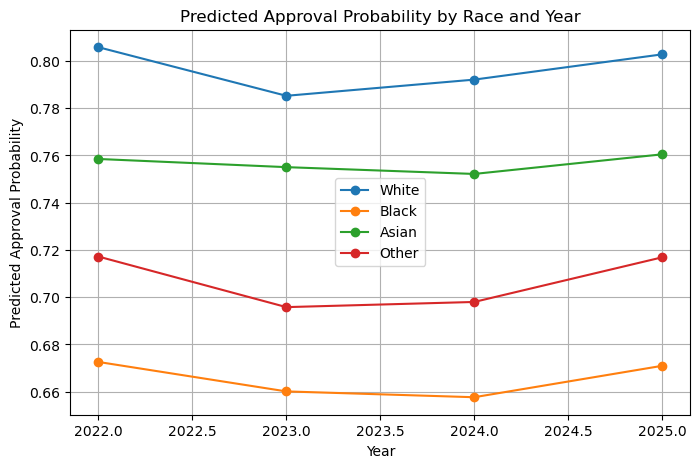

In [13]:
plt.figure(figsize=(8, 5))

for race in pred_grid["race_group"].unique():
    temp = pred_grid[pred_grid["race_group"] == race]
    plt.plot(
        temp["activity_year"],
        temp["predicted_prob"],
        marker="o",
        label=race
    )

plt.xlabel("Year")
plt.ylabel("Predicted Approval Probability")
plt.title("Predicted Approval Probability by Race and Year")
plt.legend()
plt.grid(True)
plt.show()

## Step 12. Interpretation

The predicted probability plot makes the regression results easier to interpret.

If the predicted approval probabilities for racial groups move in parallel over time, then demographic disparities appear relatively stable.

If the gaps between groups become larger, smaller, or change direction, then the evidence suggests that demographic disparities changed across years.

## Step 13. Save prediction results

In [14]:
output_path = os.path.join(downloads_path, "rq3_predicted_probabilities.csv")

pred_grid.to_csv(output_path, index=False)

print("Saved prediction results to:")
print(output_path)

Saved prediction results to:
/Users/brian/Downloads/rq3_predicted_probabilities.csv


## Final interpretation

Based on this notebook, I would interpret the research question in the following way:

Some key determinants of mortgage approval, especially income and loan amount, appear to be relatively stable over time. These variables remain consistently related to approval outcomes across years.

However, demographic disparities do not look perfectly constant. The interaction model and predicted probability plots suggest that approval gaps across racial groups can change from year to year. In some years the gaps become wider, while in other years they narrow.

This means that mortgage approval patterns are shaped not only by stable applicant-level financial characteristics, but also by changes in the broader lending environment. In other words, findings from a single year may not fully represent the dynamics of the mortgage market across time.

Overall, the evidence suggests that the main determinants of approval are fairly stable, but the magnitude of demographic disparities shifts over time rather than remaining completely fixed.